In [1]:
# Generic imports
from collections import Counter
from warnings import filterwarnings
# filterwarnings(action='ignore')  # Uncoment if required

import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt


from sklearn.decomposition import NMF, PCA, LatentDirichletAllocation
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import rand_score

import spacy
from spacy import displacy

In [2]:
# Setting globally figure size in the notebook
plt.rcParams["figure.figsize"] = (8.0, 6.0)

# Brand colors dictionary
brand_colors = {
    "Denim": "#1358DB",
    "Supernova": "#FFCF00",
    # "Black": "#000000",
    # "Dark Blue": "#101D42",
    # "White": "#FFFFFF",
    "Dark Gray": "#6F6F6F",
    # "Light Gray 1": "#F6F6F4",
    "Light Gray 2": "#ADBDCC"
}

# Create a matplotlib colormap
brand_cmap = plt.cm.colors.ListedColormap(list(brand_colors.values()))
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=brand_colors.values())

# Numpy settings
np.random.seed(12345)

# Setting pandas display options
pd.set_option('display.max_colwidth', 200)

In [3]:
# ============================================================
# HMDA 2024 — Clean notebook baseline (UPDATED + WORKING)
# 1) Load HMDA CSV
# 2) Apply Excel "red highlight" refinement rules:
#    - drop red fields (columns) when the FIELD ROW is red
#    - for value-level red codes:
#         * DEFAULT: set those entries to NA (keep row)
#         * EXCEPT for certain "choice" columns: DROP those rows entirely
#    - drop rows ONLY for red values in a small whitelist of required fields
#    - IMPORTANT: NEVER null-out action_taken (keep outcomes intact)
# 3) Dictionary-aligned cleaning:
#    - action_taken labels
#    - denial_reason cleaning (10, 1111 -> NA for analysis)
# ============================================================

import numpy as np
import pandas as pd
from IPython.display import display

from openpyxl import load_workbook
from collections import defaultdict
import difflib

# -------------------------
# PATHS
# -------------------------
HMDA_CSV_PATH = "/Users/charlescai/Desktop/BrainStation/Sprint 2/2024_public_lar_csv.csv"
REFINEMENT_XLSX_PATH = "/Users/charlescai/Downloads/HMDA field refinment.xlsx"
SHEET_NAME = "Sheet1"

# -------------------------
# OPTIONAL: Manual mapping for Excel field name -> CSV column name
# Use this ONLY for fields that appear in "unmatched" report.
# -------------------------
MANUAL_FIELD_MAP = {
    # Fill only if needed, e.g.:
    # "Type of Purchaser": "purchaser_type",
}

# Excel generic label -> CSV column name (synonyms)
SYNONYM_FIELD_MAP = {
    "age": "applicant_age",
    "race": "derived_race",
    "ethnicity": "derived_ethnicity",
    "sex": "derived_sex",

    "application_channel": "submission_of_application",
    "credit_score": "applicant_credit_score_type",  # NOTE: this is score TYPE, not the raw score
    "type_of_purchaser": "purchaser_type",
    "total_loan_costs_or_total_points_and_fees": "total_points_and_fees",
}

# Only drop rows for red values in these columns (keep this list SMALL!)
ROW_DROP_WHITELIST = {"state_code", "derived_msa_md", "loan_amount"}

# For these "choice" columns, if a value is RED in Excel, we EXCLUDE those rows (instead of setting NA)
# (This prevents columns like loan_type becoming "1 and NaN" instead of "1 and 2".)
VALUE_DROP_COLS = {
    "loan_type",
    "loan_purpose",
    "lien_status",
    "occupancy_type",
    "construction_method",
    "preapproval",
    # add/remove as needed for your product scope
}

# Never set-to-NA for these columns even if Excel marks values red
NEVER_NULL_OUT = {"action_taken"}

# ============================================================
# 0) Load HMDA CSV
# ============================================================
df = pd.read_csv(HMDA_CSV_PATH, low_memory=False)
print("Loaded df:", df.shape)
display(df.head(3))

# ============================================================
# 1) Parse Excel highlights (red = exclude)
#    - Entire field/column may be red
#    - Certain values within a field may be red
# ============================================================

RED_RGB = {"FFC00000"}  # common solid red fill
RED_THEME = {9}         # some workbooks use theme index for red

def is_red(cell) -> bool:
    fill = cell.fill
    if not fill or fill.patternType != "solid":
        return False
    fg = fill.fgColor
    if fg.type == "rgb" and fg.rgb in RED_RGB:
        return True
    if fg.type == "theme" and fg.theme in RED_THEME:
        return True
    return False

def norm_name(x):
    """Normalize names to improve matching across Excel vs CSV."""
    if x is None:
        return None
    s = str(x).strip().lower()
    for ch in [" ", "-", "/", "(", ")", ".", ",", ":", ";", "[", "]"]:
        s = s.replace(ch, "_")
    while "__" in s:
        s = s.replace("__", "_")
    return s.strip("_")

def norm_val(v):
    """Normalize values so matching works across int/float/str."""
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return None
    if isinstance(v, (int, np.integer)):
        return int(v)
    if isinstance(v, float) and v.is_integer():
        return int(v)
    if isinstance(v, str):
        return v.strip()
    return v

wb = load_workbook(REFINEMENT_XLSX_PATH)
ws = wb[SHEET_NAME]

drop_fields_excel = set()              # Excel field identifiers for whole-field red
red_values_excel = defaultdict(set)    # Excel field identifier -> set(bad values)
current_field_excel = None

for r in range(2, ws.max_row + 1):
    field_number = ws.cell(r, 1).value
    field_name = ws.cell(r, 2).value
    data_point_name = ws.cell(r, 7).value

    # new field block when a field number appears
    if field_number is not None:
        current_field_excel = data_point_name or field_name

        # whole-field red if ANY key cell in the field header row is red
        # (safer when the entire row is red-highlighted)
        if any(is_red(ws.cell(r, c)) for c in [1, 2, 7]):
            drop_fields_excel.add(current_field_excel)

    # within-field values
    code_cell = ws.cell(r, 5)
    desc_cell = ws.cell(r, 6)
    code_val = norm_val(code_cell.value)

    if current_field_excel is not None and code_val is not None:
        # value-level red if code cell OR description cell is red
        if is_red(code_cell) or is_red(desc_cell):
            red_values_excel[current_field_excel].add(code_val)

print(f"Excel red whole-fields detected: {len(drop_fields_excel)}")
print(f"Excel fields with red values detected: {len(red_values_excel)}")

# ============================================================
# 2) Map Excel field identifiers -> df column names
# ============================================================

df_cols = list(df.columns)
df_norm_map = {norm_name(c): c for c in df_cols}

def map_field(excel_field):
    if excel_field in MANUAL_FIELD_MAP:
        return MANUAL_FIELD_MAP[excel_field]

    key = norm_name(excel_field)

    if key in SYNONYM_FIELD_MAP:
        return SYNONYM_FIELD_MAP[key]

    return df_norm_map.get(key)

mapped_drop_cols = set()
mapped_red_values = defaultdict(set)
unmatched_fields = set()

# map whole-field drops
for f in drop_fields_excel:
    col = map_field(f)
    if col is None:
        unmatched_fields.add(f)
    else:
        mapped_drop_cols.add(col)

# map red values
for f, vals in red_values_excel.items():
    col = map_field(f)
    if col is None:
        unmatched_fields.add(f)
    else:
        mapped_red_values[col].update(vals)

print(f"Matched whole-field drops to CSV columns: {len(mapped_drop_cols)}")
print(f"Matched red-values rules to CSV columns: {len(mapped_red_values)}")
print(f"Unmatched Excel fields: {len(unmatched_fields)}")

if len(unmatched_fields) > 0:
    print("\n--- Unmatched Excel fields (add MANUAL_FIELD_MAP entries if needed) ---")
    for f in list(sorted(unmatched_fields))[:30]:
        print(" •", f)

    print("\n--- Suggested matches (best-effort) ---")
    for f in list(sorted(unmatched_fields))[:15]:
        candidates = difflib.get_close_matches(
            norm_name(f),
            [norm_name(c) for c in df_cols],
            n=5,
            cutoff=0.60
        )
        suggestions = []
        for cand in candidates:
            suggestions.append(next((c for c in df_cols if norm_name(c) == cand), cand))
        print(f" {f} -> {suggestions}")

        
# ============================================================
# 2.5) OVERRIDES (if Excel highlights don't match our intent)
# ============================================================

# For these columns, we want to KEEP specific values even if Excel marked them red
KEEP_VALUE_OVERRIDES = {
    "loan_type": {1, 2},   # keep 1 & 2 no matter what Excel says
    # "loan_purpose": {...},  # add later if needed
}

def _norm_code(v):
    """Make sure 2 == 2.0 == '2' for matching."""
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return None
    if isinstance(v, (int, np.integer)):
        return int(v)
    if isinstance(v, float) and v.is_integer():
        return int(v)
    if isinstance(v, str):
        v = v.strip()
        if v.isdigit():
            return int(v)
        return v
    return v

for col, keep_vals in KEEP_VALUE_OVERRIDES.items():
    keep_vals_norm = set(_norm_code(x) for x in keep_vals)

    if col not in mapped_red_values:
        print(f"[Override] {col}: not found in mapped_red_values (nothing to override).")
        continue

    before = set(_norm_code(x) for x in mapped_red_values[col])
    after = set(v for v in before if v not in keep_vals_norm)

    mapped_red_values[col] = after
    print(f"[Override] {col}: removed keep-values from red list. Before={sorted(before)} After={sorted(after)}")
    
# ============================================================
# 3) Apply Excel rules
#    A) Drop red fields (columns)
#    B) DIAGNOSTIC: how many rows would be flagged per column (before row drop)
#    C) Apply:
#        - DEFAULT: set red values to NA (keep row)
#        - REQUIRED + CHOICE COLS: drop rows where red values appear
# ============================================================

# A) drop columns once
df_after_cols = df.drop(columns=list(mapped_drop_cols), errors="ignore")
print("\nAfter dropping columns:", df_after_cols.shape)

# B) diagnostic: run BEFORE any row drop
impact = []
for col, bad_vals in mapped_red_values.items():
    if col in df_after_cols.columns:
        hit = df_after_cols[col].isin(list(bad_vals)).mean()
        impact.append((col, float(hit), len(bad_vals)))

impact_df = (pd.DataFrame(impact, columns=["column", "pct_rows_flagged", "n_red_values"])
               .sort_values("pct_rows_flagged", ascending=False))
display(impact_df.head(30))

# helpful debug for action_taken
if "action_taken" in df_after_cols.columns:
    print("Red action_taken values (from Excel rules):", sorted(mapped_red_values.get("action_taken", [])))
    print("\nAction taken counts BEFORE applying red rules:")
    print(df_after_cols["action_taken"].value_counts(dropna=False).sort_index())

    if "action_taken" in mapped_red_values:
        bad = mapped_red_values["action_taken"]
        print("\nAction taken counts that would be FLAGGED (but NOT nulled due to NEVER_NULL_OUT):")
        print(df_after_cols.loc[df_after_cols["action_taken"].isin(list(bad)), "action_taken"]
              .value_counts(dropna=False).sort_index())
else:
    print("No action_taken column in df_after_cols (maybe dropped by Excel rules).")

# C) apply rules
df_clean = df_after_cols.copy()

# Phase 1: DEFAULT behavior = set-to-NA for red values
# (but NOT for whitelist columns, NEVER_NULL_OUT, or VALUE_DROP_COLS)
for col, bad_vals in mapped_red_values.items():
    if (
        col in df_clean.columns
        and col not in ROW_DROP_WHITELIST
        and col not in NEVER_NULL_OUT
        and col not in VALUE_DROP_COLS
    ):
        df_clean.loc[df_clean[col].isin(list(bad_vals)), col] = pd.NA

# Phase 2: drop rows for:
#   - whitelist columns (required fields)
#   - VALUE_DROP_COLS (choice fields: exclude red-coded rows)
keep_mask = pd.Series(True, index=df_clean.index)

for col, bad_vals in mapped_red_values.items():
    if col in df_clean.columns and col not in NEVER_NULL_OUT:
        if col in ROW_DROP_WHITELIST or col in VALUE_DROP_COLS:
            keep_mask &= ~df_clean[col].isin(list(bad_vals))

before_rows = len(df_clean)
df_clean = df_clean.loc[keep_mask].copy()
after_rows = len(df_clean)

print(f"\nAfter applying red rules: {df_clean.shape}")
print(f"Rows removed by red-value rules (whitelist + choice cols): {before_rows-after_rows:,}")

# OPTIONAL sanity checks for key choice columns
for c in sorted(VALUE_DROP_COLS):
    if c in df_clean.columns:
        print(f"\n{c} value_counts (after rules):")
        print(df_clean[c].value_counts(dropna=False).head(20))

# ============================================================
# 4) HMDA dictionary-aligned cleaning
#    - action_taken labels
#    - denial_reason_* cleaning: 10/1111 -> NA for reason analysis
# ============================================================

ACTION_LABELS = {
    1: "Originated",
    2: "Approved not accepted",
    3: "Denied",
    4: "Withdrawn",
    5: "Closed for incompleteness",
    6: "Purchased",
    7: "Preapproval denied",
    8: "Preapproval approved not accepted",
}

if "action_taken" in df_clean.columns:
    df_clean["action_taken"] = pd.to_numeric(df_clean["action_taken"], errors="coerce").astype("Int16")
    df_clean["action_taken_label"] = df_clean["action_taken"].map(ACTION_LABELS).astype("category")

DENIAL_COLS = [c for c in ["denial_reason_1","denial_reason_2","denial_reason_3","denial_reason_4"] if c in df_clean.columns]
SENTINELS_TO_EXCLUDE_FROM_REASON_ANALYSIS = {10, 1111}

for c in DENIAL_COLS:
    s = pd.to_numeric(df_clean[c], errors="coerce")
    s = s.where(~s.isin(SENTINELS_TO_EXCLUDE_FROM_REASON_ANALYSIS), pd.NA)
    df_clean[c] = s.astype("Int16")

DENIAL_REASON_LABELS = {
    1: "Debt-to-income ratio",
    2: "Employment history",
    3: "Credit history",
    4: "Collateral",
    5: "Insufficient cash (downpayment/closing costs)",
    6: "Unverifiable information",
    7: "Credit application incomplete",
    8: "Mortgage insurance denied",
    9: "Other",
}

for c in DENIAL_COLS:
    df_clean[c + "_label"] = df_clean[c].map(DENIAL_REASON_LABELS).astype("category")

# ============================================================
# 5) Quick KPIs / sanity checks
# ============================================================

print("\nAction Taken distribution (top):")
if "action_taken_label" in df_clean.columns:
    print(df_clean["action_taken_label"].value_counts(dropna=False).head(15))

if "action_taken" in df_clean.columns:
    overall_denial_rate = (df_clean["action_taken"] == 3).mean()
    print(f"\nDenial rate (all rows in df_clean): {overall_denial_rate:.2%}")

    apps_mask = df_clean["action_taken"].isin([1,2,3,4,5,7,8])
    apps_denial_rate = ((df_clean["action_taken"] == 3) & apps_mask).sum() / apps_mask.sum()
    print(f"Denial rate (excluding purchased): {apps_denial_rate:.2%}")

if len(DENIAL_COLS) > 0:
    print("\nMissing % by denial reason column (after cleaning 10/1111->NA):")
    print(df_clean[DENIAL_COLS].isna().mean().sort_values(ascending=False))

if "action_taken" in df_clean.columns and len(DENIAL_COLS) > 0:
    tmp = df_clean[["action_taken"] + DENIAL_COLS].copy()
    tmp["has_denial_reason"] = tmp[DENIAL_COLS].notna().any(axis=1)
    print("\nPct with ANY denial reason by action_taken:")
    display(
        tmp.groupby("action_taken")["has_denial_reason"]
           .agg(["count","mean"])
           .rename(columns={"mean":"pct_with_denial_reason"})
           .sort_index()
    )

# ============================================================
# 6) Build df_dash (small set for plotting/dashboard)
# ============================================================

DASH_COLS = [
    "action_taken","action_taken_label",
    *DENIAL_COLS, *(c + "_label" for c in DENIAL_COLS),
    "loan_type","loan_purpose","lien_status",
    "loan_amount","income",
    "state_code","derived_msa_md","census_tract",
    "debt_to_income_ratio","combined_loan_to_value_ratio",
    "interest_rate","rate_spread","property_value",
    "derived_race","derived_ethnicity","derived_sex","applicant_age"
]
DASH_COLS = [c for c in DASH_COLS if c in df_clean.columns]

df_dash = df_clean[DASH_COLS].copy()

for c in ["state_code","loan_type","loan_purpose","lien_status",
          "derived_race","derived_ethnicity","derived_sex",
          "applicant_age","debt_to_income_ratio","action_taken_label"]:
    if c in df_dash.columns:
        df_dash[c] = df_dash[c].astype("category")

def to_num(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()
    s = s.replace({"NA": np.nan, "Exempt": np.nan, "": np.nan, "nan": np.nan})
    return pd.to_numeric(s, errors="coerce")

for c in ["interest_rate","rate_spread","combined_loan_to_value_ratio","property_value"]:
    if c in df_dash.columns:
        df_dash[c + "_num"] = to_num(df_dash[c])

print("\ndf_dash ready:", df_dash.shape)
display(df_dash.head(3))

Loaded df: (12229298, 99)


,activity_year,lei,derived_msa_md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,denial_reason_2,denial_reason_3,denial_reason_4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
0,2024,WWB2V0FCW3A0EE3ZJN75,14860,CT,9190.0,09190210701,C,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Hispanic or Latino,...,NaN,NaN,NaN,5877,80.84,146500,40.0,554,1715,67
1,2024,WWB2V0FCW3A0EE3ZJN75,35300,CT,9170.0,09170194101,C,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,2045,6.26,116200,132.0,834,1455,59
2,2024,WWB2V0FCW3A0EE3ZJN75,99999,PA,42107.0,42107000700,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,3364,12.13,81400,107.0,1338,1974,0


Excel red whole-fields detected: 15
Excel fields with red values detected: 12
Matched whole-field drops to CSV columns: 15
Matched red-values rules to CSV columns: 12
Unmatched Excel fields: 0
[Override] loan_type: removed keep-values from red list. Before=[2, 3, 4] After=[3, 4]

After dropping columns: (12229298, 84)


,column,pct_rows_flagged,n_red_values
6,hoepa_status,0.999475,2
7,applicant_credit_score_type,0.731956,8
4,action_taken,0.494979,7
1,loan_purpose,0.464147,5
5,purchaser_type,0.191208,4
3,occupancy_type,0.094753,2
0,loan_type,0.089298,2
2,construction_method,0.056239,1


Red action_taken values (from Excel rules): [2, 3, 4, 5, 6, 7, 8]

Action taken counts BEFORE applying red rules:
action_taken
1    6176052
2     360560
3    2099966
4    1536699
5     581629
6    1273313
7      47427
8     153652
Name: count, dtype: int64

Action taken counts that would be FLAGGED (but NOT nulled due to NEVER_NULL_OUT):
action_taken
2     360560
3    2099966
4    1536699
5     581629
6    1273313
7      47427
8     153652
Name: count, dtype: int64

After applying red rules: (4649301, 84)
Rows removed by red-value rules (whitelist + choice cols): 7,579,997

construction_method value_counts (after rules):
construction_method
1    4649301
Name: count, dtype: int64

lien_status value_counts (after rules):
lien_status
1    4430674
2     218627
Name: count, dtype: int64

loan_purpose value_counts (after rules):
loan_purpose
1    4649301
Name: count, dtype: int64

loan_type value_counts (after rules):
loan_type
1    3475441
2    1173860
Name: count, dtype: int64

occupancy_t

,count,pct_with_denial_reason
action_taken,,
1,2625416,0.000000
2,89526,0.000000
3,288936,0.982169
4,580281,0.000000
5,71675,0.000000
6,818228,0.000000
7,40818,0.977926
8,134421,0.000000



df_dash ready: (4649301, 25)


,action_taken,action_taken_label,denial_reason_1,denial_reason_2,denial_reason_3,denial_reason_4,denial_reason_1_label,denial_reason_2_label,denial_reason_3_label,denial_reason_4_label,...,state_code,derived_msa_md,census_tract,debt_to_income_ratio,combined_loan_to_value_ratio,rate_spread,property_value,rate_spread_num,combined_loan_to_value_ratio_num,property_value_num
61,3,Denied,1,4,2,<NA>,Debt-to-income ratio,Collateral,Employment history,NaN,...,NY,45060,36053030702,50%-60%,90.63,NaN,255000,NaN,90.63,255000.0
97,1,Originated,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,...,MD,12580,24003740703,49,79.48,4.68,765000,4.68,79.48,765000.0
100,1,Originated,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,...,NY,10580,36001002000,42,68.31,3.26,195000,3.26,68.31,195000.0



0) MODELING FRAME DEFINITION
Shape: (3831073, 90)
Overall Denial Rate: 0.0754

1) ACTION TAKEN DISTRIBUTION


action_taken
1    2625416
2      89526
3     288936
4     580281
5      71675
7      40818
8     134421
Name: count, dtype: Int64


1B) ACTION TAKEN LABEL DISTRIBUTION


action_taken_label
Originated                           2625416
Withdrawn                             580281
Denied                                288936
Preapproval approved not accepted     134421
Approved not accepted                  89526
Closed for incompleteness              71675
Preapproval denied                     40818
Purchased                                  0
Name: count, dtype: int64


2) % WITH DENIAL REASON BY ACTION TAKEN


,count,pct_with_denial_reason
action_taken,,
1,2625416,0.000000
2,89526,0.000000
3,288936,0.982169
4,580281,0.000000
5,71675,0.000000
7,40818,0.977926
8,134421,0.000000



3) TOP 25 COLUMNS BY MISSINGNESS


co_applicant_ethnicity_5    0.999995
applicant_ethnicity_5       0.999984
co_applicant_ethnicity_4    0.999984
applicant_ethnicity_4       0.999954
co_applicant_race_5         0.999916
applicant_race_5            0.999789
co_applicant_race_4         0.999744
denial_reason_4             0.999689
denial_reason_4_label       0.999689
hoepa_status                0.999614
co_applicant_ethnicity_3    0.999410
applicant_race_4            0.999332
applicant_ethnicity_3       0.998353
co_applicant_race_3         0.997852
denial_reason_3_label       0.996923
denial_reason_3             0.996923
applicant_race_3            0.994594
aus_5                       0.989049
aus_4                       0.987554
denial_reason_2_label       0.980991
denial_reason_2             0.980991
aus_3                       0.969340
co_applicant_race_2         0.968092
co_applicant_ethnicity_2    0.964053
applicant_race_2            0.925034
dtype: float64


4) NUMERIC FEATURE DISTRIBUTIONS


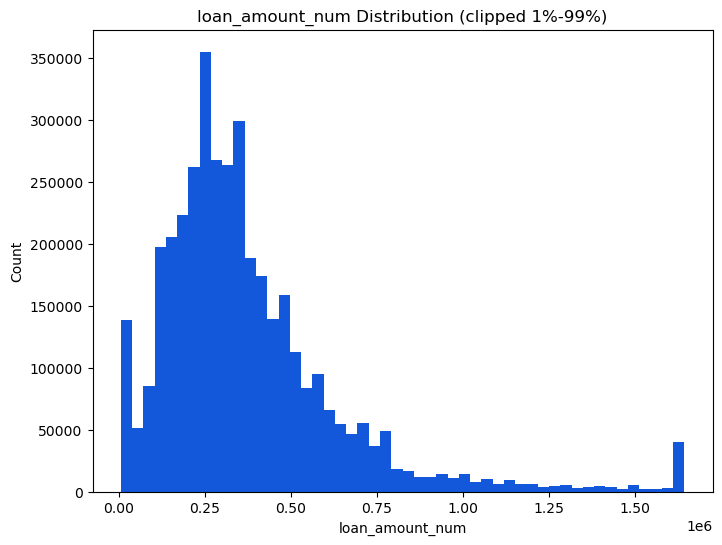

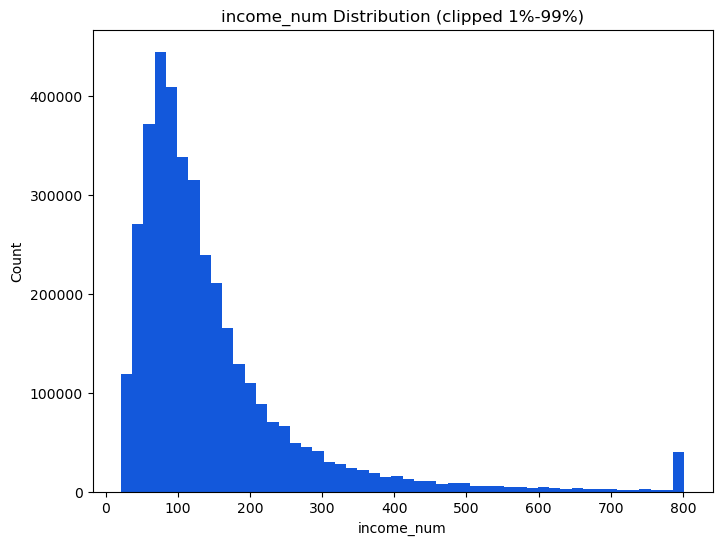

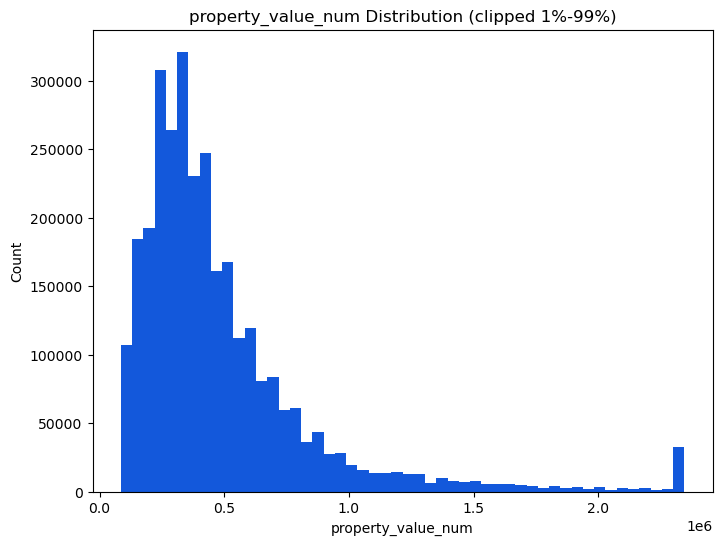

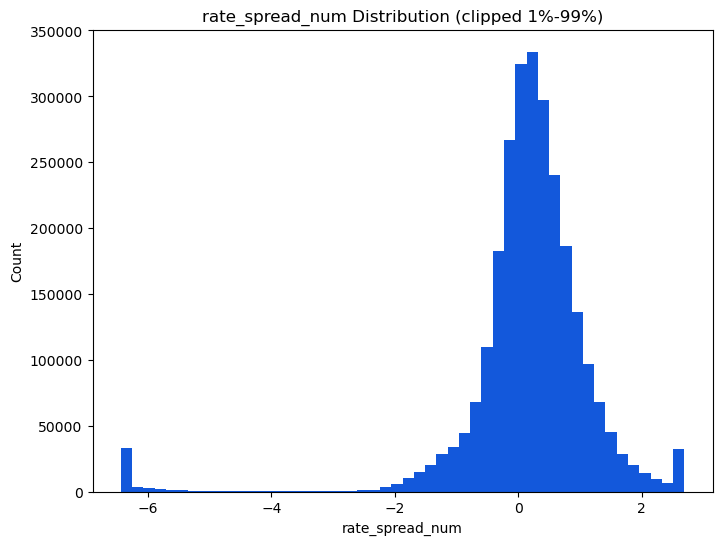

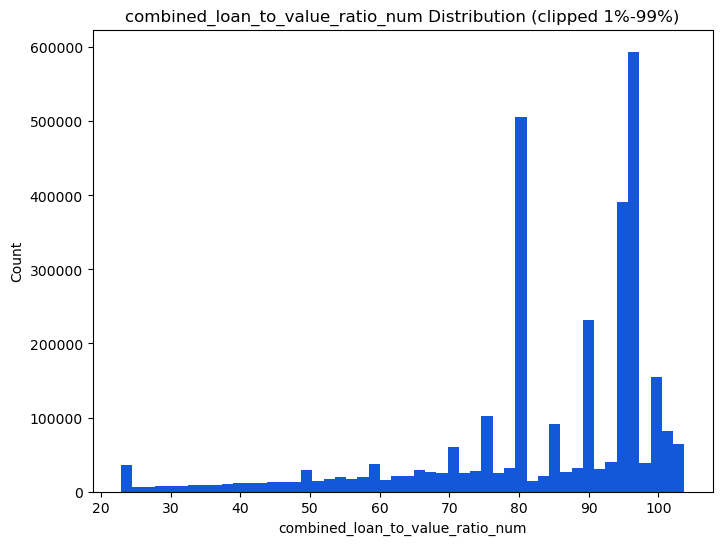


5) DENIAL RATE BY CATEGORICAL FEATURES

--- Denial Rate by loan_type ---


,count,denial_rate
loan_type,,
1,2980787,0.068262
2,850286,0.100510



--- Denial Rate by loan_purpose ---


,count,denial_rate
loan_purpose,,
1,3831073,0.075419



--- Denial Rate by lien_status ---


...

,count,denial_rate
property_value_num_q,,
Q1,337853,0.129835
Q2,320193,0.092825
Q3,262613,0.089634
Q4,326818,0.087581
Q5,304762,0.084020
Q6,302150,0.077809
Q7,300075,0.078774
Q8,298900,0.075233
Q9,313022,0.074541



7) NUMERIC CORRELATION WITH DENIAL TARGET


is_denied                           1.000000
combined_loan_to_value_ratio_num    0.002756
property_value_num                  0.000408
income_num                          0.000038
loan_amount_num                    -0.008511
rate_spread_num                          NaN
Name: is_denied, dtype: float64


8) EDA SAMPLE DATASET (FOR FAST PLOTTING)
EDA sample shape: (300000, 98)


,activity_year,lei,derived_msa_md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,action_taken,...,denial_reason_4_label,is_denied,loan_amount_num,income_num,property_value_num,rate_spread_num,combined_loan_to_value_ratio_num,income_num_q,loan_amount_num_q,property_value_num_q
1317643,2024,549300121SF0K2LN2804,11244,CA,6059.0,06059075518,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,...,NaN,0,1005000,228.0,1115000.0,0.364,90.000,Q9,Q10,Q10
4576135,2024,549300SK2GVCQXPD4S58,33340,WI,55079.0,55079013000,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,1,...,NaN,0,215000,58.0,235000.0,1.301,100.000,Q2,Q3,Q2
5677709,2024,E57ODZWZ7FF32TWEFA76,26420,TX,48201.0,48201555305,NC,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,...,NaN,0,775000,296.0,955000.0,0.122,80.919,Q10,Q10,Q10


In [4]:
# ============================================================
# HMDA 2024 — Classic EDA (Readable Version with Titles)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ------------------------------------------------------------
# Helper: Pretty Section Title
# ------------------------------------------------------------
def section(title):
    print("\n" + "="*80)
    print(title.upper())
    print("="*80)

# ------------------------------------------------------------
# 0) Build modeling frame
# ------------------------------------------------------------
section("0) Modeling Frame Definition")

MODEL_ACTIONS = [1, 2, 3, 4, 5, 7, 8]
df_model = df_clean[df_clean["action_taken"].isin(MODEL_ACTIONS)].copy()
df_model["is_denied"] = (df_model["action_taken"] == 3).astype(int)

print("Shape:", df_model.shape)
print("Overall Denial Rate:", round(df_model["is_denied"].mean(), 4))


# ------------------------------------------------------------
# 1) Target Distribution
# ------------------------------------------------------------
section("1) Action Taken Distribution")

display(df_model["action_taken"].value_counts().sort_index())

if "action_taken_label" in df_model.columns:
    section("1B) Action Taken Label Distribution")
    display(df_model["action_taken_label"].value_counts())


# ------------------------------------------------------------
# 2) Denial Reason Sanity Check
# ------------------------------------------------------------
DENIAL_COLS = [c for c in df_model.columns if c.startswith("denial_reason_") and not c.endswith("_label")]

if DENIAL_COLS:
    section("2) % With Denial Reason by Action Taken")

    tmp = df_model[["action_taken"] + DENIAL_COLS].copy()
    tmp["has_denial_reason"] = tmp[DENIAL_COLS].notna().any(axis=1)

    display(
        tmp.groupby("action_taken")["has_denial_reason"]
           .agg(["count","mean"])
           .rename(columns={"mean":"pct_with_denial_reason"})
           .sort_index()
    )


# ------------------------------------------------------------
# 3) Missingness Overview
# ------------------------------------------------------------
section("3) Top 25 Columns by Missingness")

missing = df_model.isna().mean().sort_values(ascending=False)
display(missing.head(25))


# ------------------------------------------------------------
# 4) Numeric Distribution Plots
# ------------------------------------------------------------
section("4) Numeric Feature Distributions")

def to_num(series):
    s = series.astype(str).str.strip()
    s = s.replace({"NA": np.nan, "Exempt": np.nan, "": np.nan, "nan": np.nan})
    return pd.to_numeric(s, errors="coerce")

NUM_CANDIDATES = ["loan_amount", "income", "property_value",
                  "interest_rate", "rate_spread", "combined_loan_to_value_ratio"]

for c in NUM_CANDIDATES:
    if c in df_model.columns:
        df_model[c + "_num"] = to_num(df_model[c])

def hist_clip(s, title, clip_q=(0.01, 0.99), bins=50):
    s = s.dropna()
    if len(s) == 0:
        return
    lo, hi = s.quantile(list(clip_q))
    s2 = s.clip(lo, hi)

    plt.figure()
    plt.hist(s2, bins=bins)
    plt.title(f"{title} Distribution (clipped {clip_q[0]:.0%}-{clip_q[1]:.0%})")
    plt.xlabel(title)
    plt.ylabel("Count")
    plt.show()

for c in [x + "_num" for x in NUM_CANDIDATES if x in df_model.columns]:
    hist_clip(df_model[c], c)


# ------------------------------------------------------------
# 5) Denial Rate by Categorical Features
# ------------------------------------------------------------
section("5) Denial Rate by Categorical Features")

def denial_rate_by(col, top_n=20):
    grp = (df_model.groupby(col)["is_denied"]
           .agg(["count","mean"])
           .rename(columns={"mean":"denial_rate"})
           .sort_values("count", ascending=False))
    display(grp.head(top_n))

CATEGORICAL_BREAKDOWNS = [
    "loan_type", "loan_purpose", "lien_status",
    "debt_to_income_ratio",
    "state_code",
    "derived_race", "derived_ethnicity",
    "derived_sex", "applicant_age",
]

for col in CATEGORICAL_BREAKDOWNS:
    if col in df_model.columns:
        print(f"\n--- Denial Rate by {col} ---")
        denial_rate_by(col, 25)


# ------------------------------------------------------------
# 6) Denial Rate by Quantiles (Numeric Bucketing)
# ------------------------------------------------------------
section("6) Denial Rate by Numeric Quantiles")

def denial_by_quantile(num_col, q=10):
    labels = [f"Q{i+1}" for i in range(q)]
    df_model[num_col + "_q"] = pd.qcut(df_model[num_col], q,
                                       labels=labels, duplicates="drop")

    out = df_model.groupby(num_col + "_q")["is_denied"] \
                   .agg(["count","mean"]) \
                   .rename(columns={"mean":"denial_rate"})
    display(out)

for col in ["income_num", "loan_amount_num", "property_value_num"]:
    if col in df_model.columns:
        print(f"\n--- Denial Rate by {col} Quantiles ---")
        denial_by_quantile(col, 10)


# ------------------------------------------------------------
# 7) Correlation with Target (Numeric Only)
# ------------------------------------------------------------
section("7) Numeric Correlation with Denial Target")

NUM_FOR_CORR = [c for c in df_model.columns if c.endswith("_num")]

if NUM_FOR_CORR:
    corr = df_model[NUM_FOR_CORR + ["is_denied"]] \
            .corr(numeric_only=True)["is_denied"] \
            .sort_values(ascending=False)
    display(corr)


# ------------------------------------------------------------
# 8) Create Fast EDA Sample
# ------------------------------------------------------------
section("8) EDA Sample Dataset (For Fast Plotting)")

df_eda = df_model.sample(n=min(len(df_model), 300_000),
                         random_state=42)

print("EDA sample shape:", df_eda.shape)
display(df_eda.head(3))

## Modelling

In [5]:
df_model["loan_amount_num"] = pd.to_numeric(df_model["loan_amount"], errors="coerce")
df_model["income_num"] = pd.to_numeric(df_model["income"], errors="coerce")
df_model["property_value_num"] = pd.to_numeric(df_model["property_value"], errors="coerce")
df_model["combined_loan_to_value_ratio_num"] = pd.to_numeric(
    df_model["combined_loan_to_value_ratio"], errors="coerce"
)

Created *_num columns: ['loan_amount_num', 'income_num', 'property_value_num', 'combined_loan_to_value_ratio_num', 'rate_spread_num', 'total_loan_costs_num', 'loan_term_num']
loan_term_years_num median: 30.0
0) MODELING FRAME DEFINITION
Shape: (4649301, 100)
Overall denial rate: 0.06214611615810635
Num cols present now: ['loan_amount_num', 'income_num', 'property_value_num', 'combined_loan_to_value_ratio_num', 'rate_spread_num', 'total_loan_costs_num', 'loan_term_num', 'ltv_num', 'down_payment_num', 'loan_term_years_num']

1) FEATURE LIST (BASELINE)
Using n_features: 10
['loan_type', 'loan_purpose', 'debt_to_income_ratio', 'state_code', 'loan_amount_num', 'income_num', 'property_value_num', 'ltv_num', 'loan_term_years_num', 'rate_spread_num']

2) COLUMN TYPES
Numeric cols: ['loan_amount_num', 'income_num', 'property_value_num', 'ltv_num', 'loan_term_years_num', 'rate_spread_num']
Categorical cols: ['loan_type', 'loan_purpose', 'debt_to_income_ratio', 'state_code']

3) TRAIN/TEST SPLIT


,feature,coefficient,abs_coef
27,cat__debt_to_income_ratio_>60%,4.009341,4.009341
10,cat__debt_to_income_ratio_30%-<36%,-1.584959,1.584959
25,cat__debt_to_income_ratio_50%-60%,1.271157,1.271157
69,cat__state_code_PR,1.173165,1.173165
8,cat__loan_purpose_1,-0.925402,0.925402
0,num__loan_amount_num,-0.897331,0.897331
7,cat__loan_type_2,-0.618640,0.618640
41,cat__state_code_HI,0.587709,0.587709
74,cat__state_code_TX,-0.471128,0.471128
11,cat__debt_to_income_ratio_36,-0.454488,0.454488



6) EVALUATION
ROC AUC: 0.7944
Avg Precision (PR AUC-ish): 0.4112

Confusion matrix @0.50 threshold:
[[868313   3761]
 [ 43492  14295]]

Classification report @0.50 threshold:
              precision    recall  f1-score   support

           0     0.9523    0.9957    0.9735    872074
           1     0.7917    0.2474    0.3770     57787

    accuracy                         0.9492    929861
   macro avg     0.8720    0.6215    0.6752    929861
weighted avg     0.9423    0.9492    0.9364    929861


7) PLOTS


<Figure size 800x600 with 0 Axes>

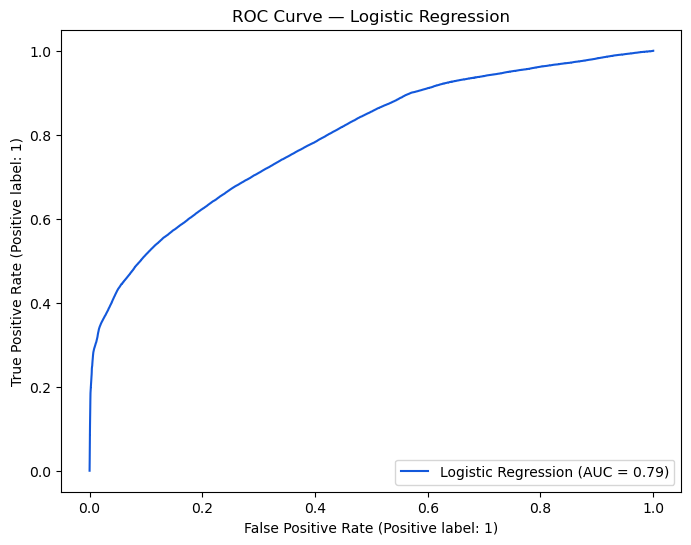

<Figure size 800x600 with 0 Axes>

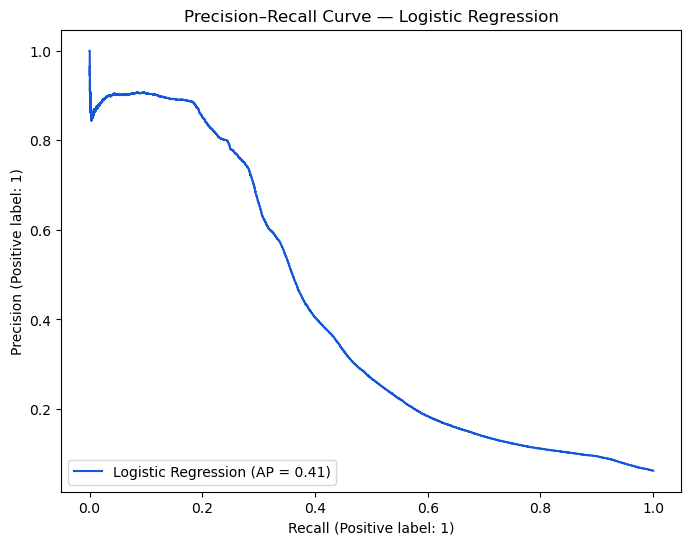


8) THRESHOLD SWEEP (OPTIONAL)


,threshold,precision,recall,f1
3,0.20,0.517738,0.354838,0.421082
4,0.25,0.708787,0.289356,0.410946
2,0.15,0.375175,0.422154,0.397280
5,0.30,0.769625,0.260093,0.388794
6,0.35,0.784989,0.248862,0.377915
7,0.40,0.786180,0.248464,0.377594
8,0.45,0.791045,0.247634,0.377189
9,0.50,0.791704,0.247374,0.376963
1,0.10,0.290247,0.479658,0.361653
0,0.05,0.124557,0.744423,0.213406


In [6]:
# ============================================================
# BASELINE MODEL — Sklearn Pipeline (Logistic Regression)
# Proper preprocessing to avoid "Exempt" -> float errors
# Target: is_denied = 1 if action_taken == 3 else 0
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

import matplotlib.pyplot as plt


# -------------------------
# 0) Define target
# -------------------------
# df_clean should already exist from your cleaning step
# action_taken: 3 = Denied
df_model = df_clean.copy()


# ---------- helper: robust numeric conversion ----------
def to_num(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()
    s = s.replace({
        "NA": np.nan,
        "Exempt": np.nan,
        "nan": np.nan,
        "": np.nan,
        "None": np.nan
    })
    return pd.to_numeric(s, errors="coerce")

# ---------- numeric versions for app-style fields ----------
NUM_BASE = ["loan_amount", "income", "property_value", "combined_loan_to_value_ratio", "rate_spread", "total_loan_costs", "loan_term"]
for c in NUM_BASE:
    if c in df_model.columns and (c + "_num") not in df_model.columns:
        df_model[c + "_num"] = to_num(df_model[c])

print("Created *_num columns:", [c for c in df_model.columns if c.endswith("_num")])

# ---------- derived feature: LTV ----------
# LTV = loan_amount / property_value
if "loan_amount_num" in df_model.columns and "property_value_num" in df_model.columns:
    df_model["ltv_num"] = df_model["loan_amount_num"] / df_model["property_value_num"]
    df_model["ltv_num"] = df_model["ltv_num"].replace([np.inf, -np.inf], np.nan).clip(0, 2)

# optional: down payment (can be useful for UI display, not necessary for model)
if "loan_amount_num" in df_model.columns and "property_value_num" in df_model.columns:
    df_model["down_payment_num"] = (df_model["property_value_num"] - df_model["loan_amount_num"]).clip(lower=0)

# ---------- loan term sanity: sometimes in months, sometimes years ----------
# If your loan_term looks like 360, 240 etc -> treat as months and convert to years.
if "loan_term_num" in df_model.columns:
    med = df_model["loan_term_num"].median(skipna=True)
    if pd.notna(med) and med > 100:  # heuristic: likely months
        df_model["loan_term_years_num"] = df_model["loan_term_num"] / 12.0
    else:
        df_model["loan_term_years_num"] = df_model["loan_term_num"]

print("loan_term_years_num median:", df_model["loan_term_years_num"].median(skipna=True))

df_model = df_model[df_model["action_taken"].notna()].copy()
df_model["is_denied"] = (df_model["action_taken"].astype(int) == 3).astype(int)

print("=" * 90)
print("0) MODELING FRAME DEFINITION")
print("=" * 90)
print("Shape:", df_model.shape)
print("Overall denial rate:", df_model["is_denied"].mean())



# -------------------------
# 0.5) Create numeric versions (must be AFTER df_model is created)
# -------------------------
NUM_SOURCE_MAP = {
    "loan_amount_num": "loan_amount",
    "income_num": "income",
    "property_value_num": "property_value",
    "combined_loan_to_value_ratio_num": "combined_loan_to_value_ratio",
    # optional if you want it:
    "rate_spread_num": "rate_spread",
}

for new_col, src_col in NUM_SOURCE_MAP.items():
    if src_col in df_model.columns:
        # handle strings like "Exempt", "NA", etc.
        s = df_model[src_col].astype(str).str.strip()
        s = s.replace({"NA": np.nan, "Exempt": np.nan, "nan": np.nan, "": np.nan})
        df_model[new_col] = pd.to_numeric(s, errors="coerce")
    else:
        print(f"WARNING: source column missing in df_model: {src_col}")



# -------------------------
# 1) Feature list (baseline)
# IMPORTANT: use *_num columns for numeric features to avoid 'Exempt'
# -------------------------
BASELINE_FEATURES = [
    # categoricals
    "loan_type",
    "loan_purpose",
    #"lien_status",
    "debt_to_income_ratio",
    "state_code",
    #"applicant_credit_score_type",      # optional (type, not score)
    #"co_applicant_credit_score_type",   # optional

    # numerics
    "loan_amount_num",
    "income_num",
    "property_value_num",
    #"combined_loan_to_value_ratio_num",
    "ltv_num",
    "loan_term_years_num",
    'rate_spread_num',

    # optional numeric add (often “Exempt” -> handled by _num):
    #"total_loan_costs_num",
]

print("Num cols present now:", [c for c in df_model.columns if c.endswith("_num")])

# Keep only features that exist
FEATURES = [c for c in BASELINE_FEATURES if c in df_model.columns]
print("\n" + "=" * 90)
print("1) FEATURE LIST (BASELINE)")
print("=" * 90)
print(f"Using n_features: {len(FEATURES)}")
print(FEATURES)

X = df_model[FEATURES].copy()
y = df_model["is_denied"].copy()


# -------------------------
# 2) Column types
# -------------------------
# Define numeric as *_num explicitly (robust)
num_cols = [c for c in FEATURES if c.endswith("_num")]
cat_cols = [c for c in FEATURES if c not in num_cols]

print("\n" + "=" * 90)
print("2) COLUMN TYPES")
print("=" * 90)
print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)


# -------------------------
# 3) Train/test split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 90)
print("3) TRAIN/TEST SPLIT")
print("=" * 90)
print("Train shape:", X_train.shape, " Denial rate:", y_train.mean())
print("Test shape :", X_test.shape,  " Denial rate:", y_test.mean())


# -------------------------
# 4) Preprocessing + model
# -------------------------
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False)),  # safe for sparse later
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(
        max_iter=2000,
        solver="lbfgs",
        n_jobs=None,
        class_weight=None
    ))
])

print("\n" + "=" * 90)
print("4) LOGISTIC REGRESSION PIPELINE")
print("=" * 90)


# -------------------------
# 5) Fit model
# -------------------------
print("\n" + "=" * 90)
print("5) FIT MODEL")
print("=" * 90)

clf.fit(X_train, y_train)
print("Done.")


# ============================================================
# EXTRACT LOGISTIC REGRESSION COEFFICIENTS
# ============================================================

print("\n" + "="*90)
print("LOGISTIC REGRESSION COEFFICIENTS")
print("="*90)

# 1️⃣ Get trained logistic model
log_model = clf.named_steps["model"]

# 2️⃣ Get preprocessor
preprocessor = clf.named_steps["preprocess"]

# 3️⃣ Get feature names AFTER preprocessing
feature_names = preprocessor.get_feature_names_out()

# 4️⃣ Extract coefficients
coefs = log_model.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "abs_coef": np.abs(coefs)
})

coef_df = coef_df.sort_values("abs_coef", ascending=False)

display(coef_df.head(20))



# -------------------------
# 6) Evaluation
# -------------------------
print("\n" + "=" * 90)
print("6) EVALUATION")
print("=" * 90)

proba = clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.50).astype(int)

print(f"ROC AUC: {roc_auc_score(y_test, proba):.4f}")
print(f"Avg Precision (PR AUC-ish): {average_precision_score(y_test, proba):.4f}")

print("\nConfusion matrix @0.50 threshold:")
print(confusion_matrix(y_test, pred))

print("\nClassification report @0.50 threshold:")
print(classification_report(y_test, pred, digits=4))


# -------------------------
# 7) Plots
# -------------------------
print("\n" + "=" * 90)
print("7) PLOTS")
print("=" * 90)

plt.figure()
RocCurveDisplay.from_predictions(y_test, proba, name="Logistic Regression")
plt.title("ROC Curve — Logistic Regression")
plt.show()

plt.figure()
PrecisionRecallDisplay.from_predictions(y_test, proba, name="Logistic Regression")
plt.title("Precision–Recall Curve — Logistic Regression")
plt.show()


# -------------------------
# 8) Threshold sweep (optional)
# -------------------------
print("\n" + "=" * 90)
print("8) THRESHOLD SWEEP (OPTIONAL)")
print("=" * 90)

thresholds = np.arange(0.05, 0.55, 0.05)
rows = []
for t in thresholds:
    p = (proba >= t).astype(int)
    # precision/recall/f1 for class 1
    from sklearn.metrics import precision_score, recall_score, f1_score
    rows.append({
        "threshold": t,
        "precision": precision_score(y_test, p, zero_division=0),
        "recall": recall_score(y_test, p, zero_division=0),
        "f1": f1_score(y_test, p, zero_division=0),
    })

thr_df = pd.DataFrame(rows).sort_values("f1", ascending=False)
display(thr_df)

In [16]:
# ============================================================
# METADATA EXPORT — for your *current* baseline variation
# (works with your clf Pipeline + FEATURES/num_cols/cat_cols + thr_df)
# Predicts: P(is_denied=1) = P(denied)
# ============================================================

import os, json
import numpy as np
import pandas as pd
from datetime import datetime

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

def _safe_float(x):
    try:
        return float(x)
    except Exception:
        return None

def _cm_dict(cm):
    # [[tn, fp],[fn,tp]]
    return {"tn": int(cm[0,0]), "fp": int(cm[0,1]), "fn": int(cm[1,0]), "tp": int(cm[1,1])}

def _top_coefs_from_pipeline(clf_pipeline, top_k=25):
    """
    Returns top coefficients for LogisticRegression inside a Pipeline
    using post-preprocess feature names (incl OHE).
    Also provides odds_ratio = exp(coef).
    """
    model = clf_pipeline.named_steps["model"]
    preprocess = clf_pipeline.named_steps["preprocess"]

    feat_names = preprocess.get_feature_names_out()
    coefs = model.coef_.ravel()

    dfc = pd.DataFrame({"feature": feat_names, "coefficient": coefs})
    dfc["abs_coef"] = dfc["coefficient"].abs()
    dfc["odds_ratio"] = np.exp(dfc["coefficient"])

    top = dfc.sort_values("abs_coef", ascending=False).head(top_k)
    return top[["feature", "coefficient", "odds_ratio"]].to_dict(orient="records")

# -------------------------------------------------------------------
# REQUIREMENTS: run AFTER training + evaluation cell in your notebook
# Needs: clf, X_train, X_test, y_train, y_test, FEATURES, num_cols, cat_cols
# Optional: thr_df from your threshold sweep
# -------------------------------------------------------------------

# --- probs on TEST ---
proba_test = clf.predict_proba(X_test)[:, 1]  # P(denied)

# --- threshold-free metrics ---
metrics = {
    "roc_auc": _safe_float(roc_auc_score(y_test, proba_test)),
    "avg_precision_pr_auc": _safe_float(average_precision_score(y_test, proba_test)),
    "brier": _safe_float(brier_score_loss(y_test, proba_test)),
}

# --- default threshold (0.50) ---
pred_05 = (proba_test >= 0.50).astype(int)
cm_05 = confusion_matrix(y_test, pred_05)
metrics_at_05 = {
    "threshold": 0.50,
    "precision": _safe_float(precision_score(y_test, pred_05, zero_division=0)),
    "recall": _safe_float(recall_score(y_test, pred_05, zero_division=0)),
    "f1": _safe_float(f1_score(y_test, pred_05, zero_division=0)),
    "confusion_matrix": _cm_dict(cm_05),
    "positive_rate_pred": _safe_float(pred_05.mean()),
}

# --- chosen threshold from thr_df (best F1 by your sort) ---
chosen_threshold = None
metrics_at_chosen = None
if "thr_df" in globals() and isinstance(thr_df, pd.DataFrame) and len(thr_df) > 0:
    chosen_threshold = float(thr_df.iloc[0]["threshold"])
    pred_t = (proba_test >= chosen_threshold).astype(int)
    cm_t = confusion_matrix(y_test, pred_t)
    metrics_at_chosen = {
        "threshold": chosen_threshold,
        "precision": _safe_float(precision_score(y_test, pred_t, zero_division=0)),
        "recall": _safe_float(recall_score(y_test, pred_t, zero_division=0)),
        "f1": _safe_float(f1_score(y_test, pred_t, zero_division=0)),
        "confusion_matrix": _cm_dict(cm_t),
        "positive_rate_pred": _safe_float(pred_t.mean()),
    }

# --- pipeline details ---
preprocess = clf.named_steps["preprocess"]
model = clf.named_steps["model"]

# category levels for each categorical col (dev-friendly)
cat_levels = {}
try:
    ohe = preprocess.named_transformers_["cat"].named_steps["onehot"]
    for col, cats in zip(cat_cols, ohe.categories_):
        cat_levels[col] = [str(c) for c in cats]
except Exception:
    cat_levels = {}

# top coefficients (post-preprocess)
top_coefs = []
try:
    top_coefs = _top_coefs_from_pipeline(clf, top_k=25)
except Exception:
    top_coefs = []

# Feature engineering notes for THIS variation
feature_engineering = {
    "created_numeric_columns": [c for c in df_model.columns if c.endswith("_num")] if "df_model" in globals() else None,
    "to_num_rules": ["NA", "Exempt", "nan", "", "None -> NaN then pd.to_numeric(errors='coerce')"],
    "derived_features": {
        "ltv_num": "loan_amount_num / property_value_num (clipped to [0,2], inf->NaN)",
        "loan_term_years_num": "loan_term_num/12 if median(loan_term_num) > 100 else loan_term_num",
        "down_payment_num": "property_value_num - loan_amount_num (clipped lower=0) [UI-only, not necessarily in FEATURES]"
    },
}

# IMPORTANT: which probability are we exporting for UX?
# Here: proba = P(denied). UX can display "Approval Likelihood" = 1 - proba
serving_contract = {
    "predicts": "P(denied)",
    "approval_likelihood_formula": "P(approved) = 1 - P(denied)  (if you want UI to show approval likelihood)",
    "expected_input": "pandas.DataFrame with columns exactly in feature_list",
    "missing_values": "handled in-pipeline via SimpleImputer",
    "unknown_categories": "handled via OneHotEncoder(handle_unknown='ignore')",
    "recommended_threshold_for_flagging_denial": chosen_threshold,  # can be None
}

model_metadata = {
    "model_name": "baseline_logreg_variation_v1",  # <-- rename if needed
    "created_at_utc": datetime.utcnow().isoformat() + "Z",
    "problem": "binary_classification",
    "target": {
        "name": "is_denied",
        "definition": "1 if action_taken == 3 (Denied), else 0",
        "positive_class": 1,
        "predict_proba_contract": "predict_proba(X)[:, 1] = P(is_denied=1) = P(denied)",
    },
    "data_split": {
        "random_state": 42,
        "test_size": 0.20,
        "stratify": True,
    },
    "data_summary": {
        "n_train": int(len(X_train)),
        "n_test": int(len(X_test)),
        "train_denial_rate": _safe_float(float(np.mean(y_train))),
        "test_denial_rate": _safe_float(float(np.mean(y_test))),
    },
    "features": {
        "feature_list": list(FEATURES),
        "numeric_features": list(num_cols),
        "categorical_features": list(cat_cols),
        "feature_engineering": feature_engineering,
    },
    "preprocessing": {
        "numeric": {
            "imputer": "median",
            "scaler": "StandardScaler(with_mean=False)",
        },
        "categorical": {
            "imputer": "most_frequent",
            "one_hot_encoder": {
                "handle_unknown": "ignore",
                "categories": cat_levels,   # includes debt_to_income_ratio categories
            },
        },
    },
    "model": {
        "type": "sklearn.linear_model.LogisticRegression",
        "params": model.get_params(),
    },
    "metrics_test": {
        **metrics,
        "at_threshold_0_5": metrics_at_05,
        "at_chosen_threshold": metrics_at_chosen,
    },
    "interpretability": {
        "note": "Coefficients are log-odds after preprocessing. odds_ratio = exp(coef). "
                "For one-hot features, coef compares that category vs the dropped baseline category.",
        "top_coefficients": top_coefs,
    },
    "serving": serving_contract,
}

# -------------------------
# SAVE METADATA JSON
# -------------------------
EXPORT_DIR = "/Users/charlescai/Desktop/BrainStation/Sprint 2"  # <-- change to your real folder
os.makedirs(EXPORT_DIR, exist_ok=True)  # safe even if it already exists

META_PATH = os.path.join(EXPORT_DIR, f"{model_metadata['model_name']}.metadata.json")

with open(META_PATH, "w") as f:
    json.dump(model_metadata, f, indent=2)

print("Saved metadata to:", META_PATH)
print("Model predicts:", model_metadata["serving"]["predicts"])
print("Recommended threshold:", model_metadata["serving"]["recommended_threshold_for_flagging_denial"])

Saved metadata to: /Users/charlescai/Desktop/BrainStation/Sprint 2/baseline_logreg_variation_v1.metadata.json
Model predicts: P(denied)
Recommended threshold: 0.2


### Tree-based


TREE MODEL: HistGradientBoostingClassifier

Features used: 14
Numeric: ['loan_amount_num', 'income_num', 'property_value_num', 'combined_loan_to_value_ratio_num', 'ltv_num', 'loan_term_years_num', 'total_loan_costs_num']
Categorical: ['loan_type', 'loan_purpose', 'lien_status', 'debt_to_income_ratio', 'state_code', 'applicant_credit_score_type', 'co_applicant_credit_score_type']

Train denial rate: 0.1717
Test denial rate : 0.1717

FIT

EVALUATION
ROC AUC: 0.9608
Avg Precision (PR AUC-ish): 0.8437

Confusion matrix @0.50:
[[1961300   64567]
 [ 146446  273547]]

Classification report @0.50:
              precision    recall  f1-score   support

           0     0.9305    0.9681    0.9490   2025867
           1     0.8090    0.6513    0.7217    419993

    accuracy                         0.9137   2445860
   macro avg     0.8698    0.8097    0.8353   2445860
weighted avg     0.9097    0.9137    0.9099   2445860



<Figure size 800x600 with 0 Axes>

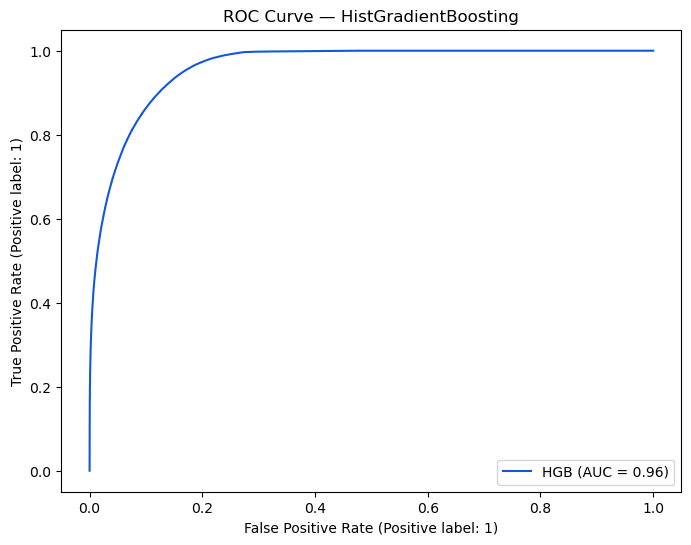

<Figure size 800x600 with 0 Axes>

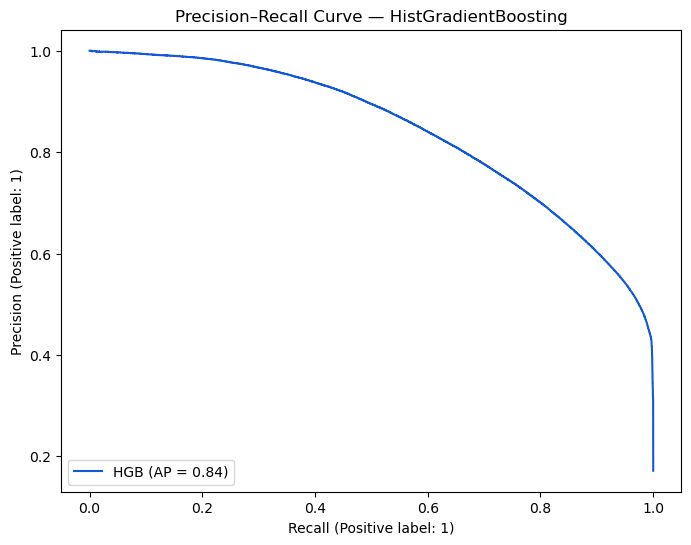

In [33]:
# ============================================================
# TREE-BASED MODEL — HistGradientBoosting (sklearn)
# Uses same FEATURES and same target as baseline
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)

print("\n" + "="*90)
print("TREE MODEL: HistGradientBoostingClassifier")
print("="*90)

# ---- Target ----
y = df_model["is_denied"].astype(int)

# ---- Features (reuse the same FEATURES from your logistic run) ----
X = df_model[FEATURES].copy()

# ---- Column types ----
num_cols = [c for c in FEATURES if c.endswith("_num") or c in ["ltv_num", "loan_term_years_num"]]
cat_cols = [c for c in FEATURES if c not in num_cols]

print("\nFeatures used:", len(FEATURES))
print("Numeric:", num_cols)
print("Categorical:", cat_cols)

# ---- Split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("\nTrain denial rate:", y_train.mean().round(4))
print("Test denial rate :", y_test.mean().round(4))

# ---- Preprocess ----
# Trees don't need scaling. Just impute numeric; OHE categoricals.
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),  # HGB prefers dense
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

# ---- Model ----
hgb = HistGradientBoostingClassifier(
    learning_rate=0.08,
    max_depth=6,
    max_iter=300,
    min_samples_leaf=50,
    random_state=42
)

tree_clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", hgb)
])

# ---- Fit ----
print("\n" + "="*90)
print("FIT")
print("="*90)

tree_clf.fit(X_train, y_train)

# ---- Evaluate ----
print("\n" + "="*90)
print("EVALUATION")
print("="*90)

proba = tree_clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.50).astype(int)

print(f"ROC AUC: {roc_auc_score(y_test, proba):.4f}")
print(f"Avg Precision (PR AUC-ish): {average_precision_score(y_test, proba):.4f}")

print("\nConfusion matrix @0.50:")
print(confusion_matrix(y_test, pred))

print("\nClassification report @0.50:")
print(classification_report(y_test, pred, digits=4))

# ---- Plots ----
plt.figure()
RocCurveDisplay.from_predictions(y_test, proba, name="HGB")
plt.title("ROC Curve — HistGradientBoosting")
plt.show()

plt.figure()
PrecisionRecallDisplay.from_predictions(y_test, proba, name="HGB")
plt.title("Precision–Recall Curve — HistGradientBoosting")
plt.show()

In [34]:
print(proba.min(), proba.max())
print(np.percentile(proba, [1,5,10,50,90,95,99]))

2.242109376450811e-06 0.9997807576869615
[8.48742135e-06 1.24175365e-05 1.53666091e-05 1.51412442e-02
 6.30315805e-01 8.90429472e-01 9.84964959e-01]
